In [1]:
import pyomo.environ as pyo
import idaes
import math
import pandas as pd
import numpy as np
from scipy import stats
import pyomo.dae as dae
import matplotlib.pyplot as plt
from pyomo.contrib.parmest.experiment import Experiment
from pyomo.contrib.doe import DesignOfExperiments
from pyomo.contrib.parmest import parmest
from scipy.stats import chi2
import matplotlib.lines as mlines
from matplotlib.patches import Patch

# Create the class and functions to be used in this notebook

In [2]:
class BatchReactorExperiment(Experiment):
    """Creates and labels the Pyomo model of the batch reactor
    
    Parameters
    ----------
    data: Pandas.DataFrame or .csv file,
        Data containing the sample time and measured values of mass fractions 
    XA0: float,
        Initial mass fraction of species A
    temp_control: int, float, list, or dict,
        Constant or piecewise-linear profile of the reaction temperature (in R)
    const_temp: Boolean,
        Species if the batch reactor is a constant or variable temperature system
    doe_solve: Boolean,
        Species if the batch reactor model is being used for optimal experimental design
    prior_est: Boolean,
        Specifies if prior information is to be included
    expert_profile: Boolean,
        Specifies if we are using an expert intuition for the temperature profile

    Returns
    -------
    m: annotated Pyomo model of the batch reactor
    """

    def __init__(self, XA0, temp_control, const_temp, data=None, doe_solve=False,):
        self.data = data
        self.XA0 = XA0
        self.temp_control = temp_control
        self.const_temp = const_temp
        self.doe_solve = doe_solve
        self.model = None

    def get_labeled_model(self):
        self.create_model()
        self.label_model()

        return self.model

    def create_model(self):
        if self.const_temp and not self.doe_solve:
            self.model = reform_const_temp_reactor_model(self.XA0, self.temp_control)
        elif not self.const_temp and self.doe_solve:
            self.model = reform_optimal_exp_design_model(self.XA0, self.temp_control)

        return self.model

    def label_model(self):

        m = self.model
        
        meas_time_points = self.data["Time (hr)"]
    
        # label the measured variables
        m.experiment_outputs = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.experiment_outputs.update(
            (m.XA[t], self.data["XA"][ind]) for ind, t in enumerate(meas_time_points)
        )
        m.experiment_outputs.update(
            (m.XB[t], self.data["XB"][ind]) for ind, t in enumerate(meas_time_points)
        )
        m.experiment_outputs.update(
            (m.XC[t], self.data["XC"][ind]) for ind, t in enumerate(meas_time_points)
        )
        m.experiment_outputs.update(
            (m.XP[t], self.data["XP"][ind]) for ind, t in enumerate(meas_time_points)
        )
        m.experiment_outputs.update(
            (m.XE[t], self.data["XE"][ind]) for ind, t in enumerate(meas_time_points)
        )
        m.experiment_outputs.update(
            (m.XG[t], self.data["XG"][ind]) for ind, t in enumerate(meas_time_points)
        )
        
        # add the measurement errors
        m.measurement_error = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.measurement_error.update(
            (m.XA[t], 0.01) for t in meas_time_points
        )
        m.measurement_error.update(
            (m.XB[t], 0.001) for t in meas_time_points
        )
        m.measurement_error.update(
            (m.XC[t], 0.001) for t in meas_time_points
        )
        m.measurement_error.update(
            (m.XP[t], 0.01) for t in meas_time_points
        )
        m.measurement_error.update(
            (m.XE[t], 0.01) for t in meas_time_points
        )
        m.measurement_error.update(
            (m.XG[t], 0.01) for t in meas_time_points
        )

        # label the unknown parameters
        m.unknown_parameters = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.unknown_parameters.update(
            (k, pyo.value(k)) for k in [m.alpha_1, m.alpha_2, m.alpha_3, m.E1, m.E2, m.E3]
        )

        return m

In [3]:
def parameter_covariance_est(exp_list,):
    """Estimates the parameters and covariance matrix of the batch reactor model 
    from the data

    Parameters
    ----------
    exp_list: list,
        List containing the BatchReactorExperiment object

    Returns
    -------
    obj: float or int,
        Value of the objective function at the estimated parameters
    theta: dict, 
        Estimated values of the model parameters
    cov: pandas.DataFrame, 
        Covariance matrix of the estimated model parameters
    """

    # create the Estimator object
    pest = parmest.Estimator(exp_list, obj_function="SSE_weighted", tee=True)
    
    # estimate the parameters
    obj, theta = pest.theta_est()

    # compute the covariance matrix of the estimated parameters
    try:
        cov = pest.cov_est(method="finite_difference")

        return obj, theta, cov
    except RuntimeError:
        return obj, theta, ["N/A"]
    

In [4]:
def ground_truth_data(measured_var):
    """Creates a Pandas dataframe for ground-truth simulation of mass fractions

    Parameters
    ----------
    measured_var: 2D numpy array or matrix,
        matrix containing ground-truth simulation of mass fractions

    Returns
    -------
    outputs: pandas.DataFrame,
        Ground-truth simulation of mass fractions 
    """
    
    # name of experimental outputs
    output_names = ["XA", "XB", "XC", "XP", "XE", "XG"]
    
    # outputs dataframe
    outputs = pd.DataFrame(measured_var, columns=output_names)
    
    print("\nThe output variables are:\n", outputs)

    return outputs


def generate_noisy_mass_fraction(
    ground_truth,
    species_cols,
    standard_dev,
    seed=10,
):
    """
    Adds Gaussian noise to the true values of the mass fractions

    Parameters
    ----------
    ground_truth: pandas.DataFrame,
        Dataframe containing the true values of the mass fractions
    species_cols: list
        List of species column names
    standard_dev: dict
        Dictionary mapping species names to standard deviations
    seed: int, optional
        Random seed for reproducibility

    Returns
    -------
    noisy_mass_frac: pandas.DataFrame,
        Dataframe containing noisy mass fractions measurements
    """

    random_nunber_gen = np.random.default_rng(seed)

    noisy_mass_frac = ground_truth.copy()

    # add a Gaussian noise
    for col in species_cols:
        # generate Gaussian noise
        noise = random_nunber_gen.normal(
            loc=0,
            scale=standard_dev[col],
            size=len(noisy_mass_frac)
        )

        # add noise to the ground truth values
        noisy_mass_frac[col] = noisy_mass_frac[col] + noise

    # enforce non-negative mass fractions
    noisy_mass_frac[species_cols] = noisy_mass_frac[species_cols].clip(lower=0)

    # get the sum of every row
    row_sums = noisy_mass_frac[species_cols].sum(axis=1)

    # divide every value in a row by its own row sum so they add to 1
    noisy_mass_frac[species_cols] = noisy_mass_frac[species_cols].div(
        row_sums,
        axis=0
    )

    return noisy_mass_frac


def synthetic_data_compiler(sample_time, mass_frac_data, csv_name):
    """Generates noisy measurement of mass fractions

    Parameters
    ----------
    sample_time:
        Timepoints (in hr) that samples were collected for mass fraction measurements
    mass_frac_data: pandas.DataFrame,
        Dataframe containing the mass fraction measurements 
    csv_name: str,
        File name for the csv

    Returns
    -------
    data: pandas.DataFrame, 
        The full data
    """
    # data columns
    column_names = ["Time (hr)", "XA", "XB", "XC", "XP", "XE", "XG"]

    # get the number of time samples
    n_samples = len(sample_time)
    
    # define a matrix that contains the sample time and mass fractions
    data_matrix = np.zeros((n_samples, 7))
    data_matrix[:, 0] = sample_time
    data_matrix[:, 1] = mass_frac_data["XA"]
    data_matrix[:, 2] = mass_frac_data["XB"]
    data_matrix[:, 3] = mass_frac_data["XC"]
    data_matrix[:, 4] = mass_frac_data["XP"]
    data_matrix[:, 5] = mass_frac_data["XE"]
    data_matrix[:, 6] = mass_frac_data["XG"]
    
    # number of data columns
    n_columns = len(column_names)
    
    # full data
    data = pd.DataFrame(data_matrix, columns=column_names)
    print("The generated data is:\n", data)
    
    data.to_csv(f"{csv_name}.csv", index=False)

    return data
    

## True value of model parameters

In [5]:
true_params = {'alpha_1': 22.51, 'alpha_2': 28.59, 'alpha_3': 36.80, 
               'E1': 120, 'E2': 150, 'E3': 200}

## High temperature constant batch reactor

In [69]:
def const_temp_reactor_model(XA0, temp, meas_sample_time, low_temp=False):
    """
    Creates a constant temperature Pyomo model for the batch reactor

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A
    temp: int or float,
        Constant reaction temperature in R
    meas_sample_time: list,
        Timepoints (in hr) to collect samples for mass fraction measurements
    low_temp: Boolean,
        Specifies if the constant reaction temperature is low or high

    Returns
    -------
    measured_variables: list containing the mass fraction of all species at the sample timepoints
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.a1 = pyo.Param(within=pyo.PositiveReals, initialize=5.9755 * 10**9)
    model.a2 = pyo.Param(within=pyo.PositiveReals, initialize=2.5962 * 10**12)
    model.a3 = pyo.Param(within=pyo.PositiveReals, initialize=9.6283 * 10**15)
    model.E1 = pyo.Param(within=pyo.PositiveReals, initialize=120)
    model.E2 = pyo.Param(within=pyo.PositiveReals, initialize=150)
    model.E3 = pyo.Param(within=pyo.PositiveReals, initialize=200)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0.0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0.0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0.0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0.0)

    # add the temperature variable
    model.T_reparam = pyo.Var(bounds=(0, 1))
    model.T_reparam.fix(1/temp)

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, bounds=(0, None))
    model.k = pyo.Var(reaction_number, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i):
        if i == 1:
            return m.k_reparam[i] == pyo.log(m.a1) - m.E1 * m.T_reparam
        elif i == 2:
            return m.k_reparam[i] == pyo.log(m.a2) - m.E2 * m.T_reparam
        else:
            return m.k_reparam[i] == pyo.log(m.a3) - m.E3 * m.T_reparam
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i):
        return m.k[i] == pyo.exp(m.k_reparam[i])
    
    model.k_eq = pyo.Constraint(
        reaction_number, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        return m.dXA[t] == - m.k[1] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        return m.dXB[t] == - (m.k[1] * m.XA[t] * m.XB[t] + m.k[2] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        return m.dXC[t] == 2 * m.k[1] * m.XA[t] * m.XB[t] - 2 * m.k[2] * m.XB[t] * m.XC[t] - m.k[3] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        return m.dXE[t] == 2 * m.k[2] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        return m.dXG[t] == 1.5 * m.k[3] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA[t0].fix(XA0)
    model.XB[t0].fix(1 - XA0)
    model.XC[t0].fix(0.0)
    model.XE[t0].fix(0.0)
    model.XG[t0].fix(0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=60, scheme="BACKWARD")
    
    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)

    # get the mass fraction of all species
    t_values = [t for t in model.t]
    print("Timepoints are:", t_values)
    XA_values = [pyo.value(model.XA[t]) for t in model.t]
    XB_values = [pyo.value(model.XB[t]) for t in model.t] 
    XC_values = [pyo.value(model.XC[t]) for t in model.t] 
    XP_values = [pyo.value(model.XP[t]) for t in model.t] 
    XE_values = [pyo.value(model.XE[t]) for t in model.t] 
    XG_values = [pyo.value(model.XG[t]) for t in model.t]

    # get the temperature
    temp_values = [1 / pyo.value(model.T_reparam) for t in model.t]

    # plot the temperature and mass fraction profiles
    fig = plt.subplots(figsize=(5, 5))

    # set the primary axis: mass fraction
    plt.plot(t_values, XA_values, label='X$_\mathbf{A}$', color='blue', linewidth=2)
    plt.plot(t_values, XB_values, label='X$_\mathbf{B}$', color='orange', linewidth=2)
    plt.plot(t_values, XC_values, label='X$_\mathbf{C}$', color='tab:cyan', linewidth=2)
    plt.plot(t_values, XP_values, label='X$_\mathbf{P}$', color='green', linewidth=2)
    plt.plot(t_values, XE_values, label='X$_\mathbf{E}$', color='purple', linewidth=2)
    plt.plot(t_values, XG_values, label='X$_\mathbf{G}$', color='black', linewidth=2)

    plt.xlabel('Time (hr)', fontsize=16, fontweight='bold')
    plt.ylabel('Mass Fraction', fontsize=16, fontweight='bold')
    plt.tick_params(axis='x', labelsize=16, direction="in", top=True, right=True)
    plt.tick_params(axis='y', labelsize=16, direction="in", top=True, right=True)

    # add legend
    # ax1.legend(prop={"weight":"bold", "size": 11}, bbox_to_anchor=(1.5, 0.5))
    plt.tight_layout()
    if low_temp:
        plt.savefig("const_low_temp_mass_profile.png")
    else:
        plt.savefig("const_high_temp_mass_profile.png")
    plt.show()

    # store the mass fraction of all species at the sample time
    measured_variables = []
    for sample_time in meas_sample_time:
        measured_variables.append([pyo.value(model.XA[sample_time]), pyo.value(model.XB[sample_time]), 
                                   pyo.value(model.XC[sample_time]), pyo.value(model.XP[sample_time]), 
                                   pyo.value(model.XE[sample_time]), pyo.value(model.XG[sample_time])])

    print("Mass fraction of species at the sample time:",measured_variables)
    return measured_variables

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

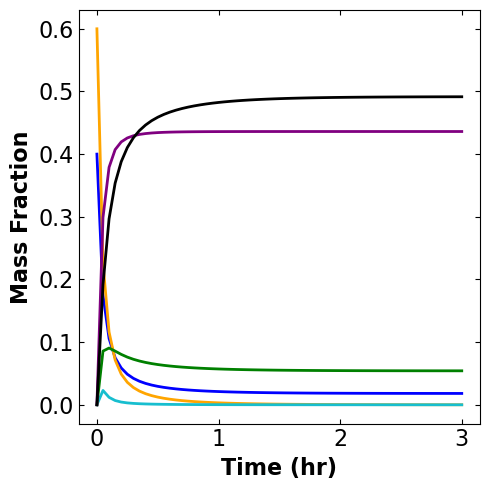

Mass fraction of species at the sample time: [[0.02943708587381165, 0.012262795363909696, 0.0008763946459984678, 0.0642238642166161, 0.43434858101980345, 0.45885127887986055], [0.019086341913254378, 0.001045778471770597, 6.391731908421214e-05, 0.05519942745576616, 0.43608112688296613, 0.48852340795715854], [0.0181015238584968, 5.248999203509859e-05, 3.1426426156195257e-06, 0.05420116291273197, 0.43609806773292353, 0.491543612861197]]

The output variables are:
          XA        XB        XC        XP        XE        XG
0  0.029437  0.012263  0.000876  0.064224  0.434349  0.458851
1  0.019086  0.001046  0.000064  0.055199  0.436081  0.488523
2  0.018102  0.000052  0.000003  0.054201  0.436098  0.491544


In [70]:
# define the constant temperature and sample time for mass fraction measurements
high_const_temp = 6.75
sample_time = [0.5, 1.5, 3]

# get the ground-truth simulation of the mass fractions
measured_var_high_temp = const_temp_reactor_model(0.4, high_const_temp, sample_time)

# make a dataframe of the measured variables
outputs_df_high_temp = ground_truth_data(measured_var_high_temp)

### Add Gaussian noise to the ground-truth simulations

In [8]:
# define the species
species = ["XA", "XB", "XC", "XP", "XE", "XG"]

# define the measurement error of the mass fraction measurements
std_dict = {
    "XA": 0.01,
    "XB": 0.001,
    "XC": 0.001,
    "XP": 0.01,
    "XE": 0.01,
    "XG": 0.01,
}

# generate the noisy mass fraction measurements
noisy_mass_frac_high = generate_noisy_mass_fraction(
    outputs_df_high_temp,
    species_cols=species,
    standard_dev=std_dict,
)

### Compile the generated data into a csv file

In [9]:
data_high_temp = synthetic_data_compiler(sample_time, noisy_mass_frac_high, 
                                         "batch_reactor_const_temp")

The generated data is:
    Time (hr)        XA        XB        XC        XP        XE        XG
0        0.5  0.018958  0.012907  0.001771  0.061513  0.443878  0.460974
1        1.5  0.011976  0.000807  0.000933  0.048212  0.440700  0.497373
2        3.0  0.010752  0.000187  0.000500  0.048153  0.445815  0.494593


### Reformulate the batch reactor model for parameter estimation

In [10]:
def reform_const_temp_reactor_model(XA0, temp):
    """
    Reformulates the constant temperature batch reactor model for parameter estimation

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A
    temp: int or float,
        Constant reaction temperature in R

    Returns
    -------
    model: Pyomo model of the batch reactor
    
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.alpha_1 = pyo.Var(bounds=(0, None), initialize=10)
    model.alpha_2 = pyo.Var(bounds=(0, None), initialize=10)
    model.alpha_3 = pyo.Var(bounds=(0, None), initialize=10)
    model.E1 = pyo.Var(bounds=(0, None), initialize=50)
    model.E2 = pyo.Var(bounds=(0, None), initialize=50)
    model.E3 = pyo.Var(bounds=(0, None), initialize=50)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0)

    # add the temperature variable
    model.T_reparam = pyo.Var(bounds=(0, 1))
    model.T_reparam.fix(1/temp)

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, bounds=(0, None))
    model.k = pyo.Var(reaction_number, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i):
        if i == 1:
            return m.k_reparam[i] == model.alpha_1 - m.E1 * m.T_reparam
        elif i == 2:
            return m.k_reparam[i] == model.alpha_2 - m.E2 * m.T_reparam
        else:
            return m.k_reparam[i] == model.alpha_3 - m.E3 * m.T_reparam
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i):
        return m.k[i] == pyo.exp(m.k_reparam[i])
    
    model.k_eq = pyo.Constraint(
        reaction_number, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXA[t] == - m.k[1] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXB[t] == - (m.k[1] * m.XA[t] * m.XB[t] + m.k[2] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXC[t] == 2 * m.k[1] * m.XA[t] * m.XB[t] - 2 * m.k[2] * m.XB[t] * m.XC[t] - m.k[3] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXE[t] == 2 * m.k[2] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXG[t] == 1.5 * m.k[3] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA_init = pyo.Constraint(expr=model.XA[t0] == XA0)
    model.XB_init = pyo.Constraint(expr=model.XB[t0] == 1 - model.XA[t0])
    model.XC_init = pyo.Constraint(expr=model.XC[t0] == 0.0)
    model.XE_init = pyo.Constraint(expr=model.XE[t0] == 0.0)
    model.XG_init = pyo.Constraint(expr=model.XG[t0] == 0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=60, scheme="BACKWARD")
    
    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)
    
    return model

In [11]:
# create an experiment class for the high temperature data
exp_high = BatchReactorExperiment(
    data=data_high_temp, XA0=0.4,
    temp_control=high_const_temp,
    const_temp=True,
)

# estimate the parameters and the covariance matrix
obj_high, estimated_params_high, cov_matrix_high = parameter_covariance_est([exp_high],)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [12]:
print("Estimate of the parameters:\n", estimated_params_high)
print("\nCovariance matrix of the estimated parameters:\n", cov_matrix_high)

Estimate of the parameters:
 {'alpha_1': 25808.811087781658, 'alpha_2': 25809.294750038003, 'alpha_3': 25809.709667394294, 'E1': 174177.62484335795, 'E2': 174174.36143907165, 'E3': 174171.56207073235}

Covariance matrix of the estimated parameters:
 ['N/A']


## Optimal reaction temperature to maximize main product P

In [13]:
def optimize_reactor_const_temp(XA0):
    """
    Creates a constant temperature Pyomo model for the batch reactor

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A

    Returns
    -------
    measured_variables: float or int, temperature that maximizes main product P formation
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.a1 = pyo.Param(within=pyo.PositiveReals, initialize=5.9755 * 10**9)
    model.a2 = pyo.Param(within=pyo.PositiveReals, initialize=2.5962 * 10**12)
    model.a3 = pyo.Param(within=pyo.PositiveReals, initialize=9.6283 * 10**15)
    model.E1 = pyo.Param(within=pyo.PositiveReals, initialize=120)
    model.E2 = pyo.Param(within=pyo.PositiveReals, initialize=150)
    model.E3 = pyo.Param(within=pyo.PositiveReals, initialize=200)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0)

    # add the temperature variable
    model.T_reparam = pyo.Var(bounds=[1/6.8, 1/5.8], initialize=1/6)

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, bounds=(0, None))
    model.k = pyo.Var(reaction_number, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i):
        if i == 1:
            return m.k_reparam[i] == pyo.log(m.a1) - m.E1 * m.T_reparam
        elif i == 2:
            return m.k_reparam[i] == pyo.log(m.a2) - m.E2 * m.T_reparam
        else:
            return m.k_reparam[i] == pyo.log(m.a3) - m.E3 * m.T_reparam
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i):
        return m.k[i] == pyo.exp(m.k_reparam[i])
    
    model.k_eq = pyo.Constraint(
        reaction_number, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        return m.dXA[t] == - m.k[1] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        return m.dXB[t] == - (m.k[1] * m.XA[t] * m.XB[t] + m.k[2] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        return m.dXC[t] == 2 * m.k[1] * m.XA[t] * m.XB[t] - 2 * m.k[2] * m.XB[t] * m.XC[t] - m.k[3] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        return m.dXE[t] == 2 * m.k[2] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        return m.dXG[t] == 1.5 * m.k[3] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA[t0].fix(XA0)
    model.XB[t0].fix(1 - pyo.value(model.XA[t0]))
    model.XC[t0].fix(0.0)
    model.XE[t0].fix(0.0)
    model.XG[t0].fix(0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=60, scheme="BACKWARD")

    # objective function
    model.obj = pyo.Objective(expr=model.XP[3], sense=pyo.maximize)
    
    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)

    return 1 / pyo.value(model.T_reparam)

In [14]:
# get the optimal reaction temperature to maximize the main product
optimal_const_temp = optimize_reactor_const_temp(0.4)

print("The optimal constant temperature is:", optimal_const_temp)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

## Constant low (optimal) temperature batch reactor

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

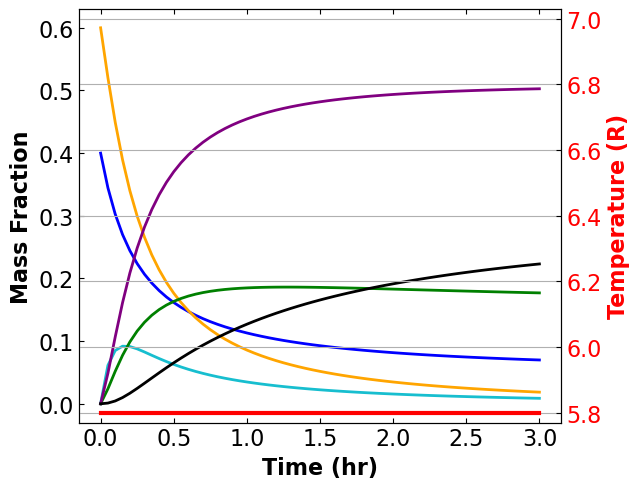

Mass fraction of species at the sample time: [[0.16163863212290347, 0.17649914735170996, 0.0628624380276193, 0.16334882065201314, 0.37027896955009576, 0.06537199229505881], [0.09268207815481715, 0.05173636753399112, 0.022318695977304116, 0.1857328473558461, 0.48189142125626144, 0.16563858972265555], [0.06991210261990598, 0.018568852705220212, 0.00872868852515366, 0.17696294668594761, 0.5026864998408634, 0.2231409096236843]]

The output variables are:
          XA        XB        XC        XP        XE        XG
0  0.161639  0.176499  0.062862  0.163349  0.370279  0.065372
1  0.092682  0.051736  0.022319  0.185733  0.481891  0.165639
2  0.069912  0.018569  0.008729  0.176963  0.502686  0.223141


In [15]:
# get the ground-truth simulation of the mass fractions
measured_var_low_temp = const_temp_reactor_model(0.4, optimal_const_temp, sample_time, 
                                                 low_temp=True)

# make a dataframe of the measured variables
outputs_df_low_temp = ground_truth_data(measured_var_low_temp)

In [16]:
# generate the noisy mass fraction measurements
noisy_mass_frac_low = generate_noisy_mass_fraction(
    outputs_df_low_temp,
    species_cols=species,
    standard_dev=std_dict,
)

# compile the generated data into a csv file
data_low_temp = synthetic_data_compiler(sample_time, noisy_mass_frac_low, 
                                        "batch_reactor_const_temp_low")

The generated data is:
    Time (hr)        XA        XB        XC        XP        XE        XG
0        0.5  0.155138  0.182086  0.065623  0.163621  0.377880  0.055653
1        1.5  0.086439  0.052095  0.023450  0.180283  0.487050  0.170684
2        3.0  0.064925  0.019548  0.009623  0.176511  0.515439  0.213953


In [17]:
# create an experiment class for the low temperature data
exp_low = BatchReactorExperiment(
    data=data_low_temp, XA0=0.4,
    temp_control=optimal_const_temp,
    const_temp=True,
)

# estimate the parameters and the covariance matrix
obj_low, estimated_params_low, cov_matrix_low = parameter_covariance_est([exp_low],)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [18]:
print("Estimate of the parameters:\n", estimated_params_low)
print("\nCovariance matrix of the estimated parameters:\n", cov_matrix_low)

Estimate of the parameters:
 {'alpha_1': 29412.657151093972, 'alpha_2': 29413.101343297058, 'alpha_3': 29412.87995005187, 'E1': 170583.04354471713, 'E2': 170580.4608668073, 'E3': 170581.73607160008}

Covariance matrix of the estimated parameters:
 ['N/A']


## Parameter estimation for combined low and high temperature data

In [19]:
# combine the high and low temperature data
exp_list_comb = [exp_high, exp_low]

# estimate the parameters and the covariance matrix
obj_comb, estimated_params_comb, cov_matrix_comb = parameter_covariance_est(exp_list_comb,)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [64]:
print("Estimate of the parameters:\n", estimated_params_comb)

print("\nCovariance matrix of the estimated parameters:\n", cov_matrix_comb)

# get the scalar metrics of the Fisher information matrix
print("The condition number of the Fisher information matrix is:\n", 
      np.linalg.cond(np.linalg.inv(cov_matrix_comb)))

print("\nThe trace of the Fisher information matrix is:\n", 
      np.trace(np.linalg.inv(cov_matrix_comb)))

Estimate of the parameters:
 {'alpha_1': 22.612703136204175, 'alpha_2': 24.053923241326, 'alpha_3': 32.64270947300112, 'E1': 120.78574655834205, 'E2': 123.98583076102585, 'E3': 176.360075992954}

Covariance matrix of the estimated parameters:
           alpha_1    alpha_2    alpha_3        E1          E2          E3
alpha_1  0.169943   0.098813   0.087169  0.987697    0.572368    0.510981
alpha_2  0.098813  12.029564  12.586695  0.572420   69.778809   73.000626
alpha_3  0.087169  12.586695  13.334203  0.511051   73.000277   77.394892
E1       0.987697   0.572420   0.511051  5.742344    3.314972    3.000545
E2       0.572368  69.778809  73.000277  3.314972  404.766050  423.385776
E3       0.510981  73.000626  77.394892  3.000545  423.385776  449.270855
The condition number of the Fisher information matrix is:
 22239317.28852629

The trace of the Fisher information matrix is:
 32838.456579625694


## Implement the temperature profile obtained from experimental design

### A-optimal design

In [21]:
# load the design conditions from optimal experimental design
trace_optimal_design = pd.read_csv("trace_optimal_design.csv")
time_vals = trace_optimal_design["Time (hr)"]
trace_optimal_temp = trace_optimal_design["Temperature (1/R)"]
trace_optimal_XA0 = trace_optimal_design["XA"][0]
print("The optimal XA0 for A-optimality is:", trace_optimal_XA0)

The optimal XA0 for A-optimality is: 0.3712258805339861


In [22]:
def optimal_exp_design_model(XA0, meas_sample_time, temp_profile, expert_profile=False):
    """
    Creates a variable temperature Pyomo model for the batch reactor

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A
    meas_sample_time: list, 
        Timepoints (in hr) to collect samples for mass fraction measurements
    temp_profile: Pandas series or list,
        Temperature profile from optimal experimental design
    expert_profile: Boolean,
        Specifies if we are using an expert intuition for the temperature profile

    Returns
    -------
    measured_variables: list containing the mass fraction of all species at the sample timepoints
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.a1 = pyo.Param(within=pyo.PositiveReals, initialize=5.9755 * 10**9)
    model.a2 = pyo.Param(within=pyo.PositiveReals, initialize=2.5962 * 10**12)
    model.a3 = pyo.Param(within=pyo.PositiveReals, initialize=9.6283 * 10**15)
    model.E1 = pyo.Param(within=pyo.PositiveReals, initialize=120)
    model.E2 = pyo.Param(within=pyo.PositiveReals, initialize=150)
    model.E3 = pyo.Param(within=pyo.PositiveReals, initialize=200)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0)

    # add the temperature variables
    model.T_reparam = pyo.Var(model.t, bounds=(0, 1))

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, model.t, bounds=(0, None))
    model.k = pyo.Var(reaction_number, model.t, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i, t):
        if i == 1:
            return m.k_reparam[i, t] == pyo.log(m.a1) - m.E1 * m.T_reparam[t]
        elif i == 2:
            return m.k_reparam[i, t] == pyo.log(m.a2) - m.E2 * m.T_reparam[t]
        else:
            return m.k_reparam[i, t] == pyo.log(m.a3) - m.E3 * m.T_reparam[t]
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i, t):
        return m.k[i, t] == pyo.exp(m.k_reparam[i, t])
    
    model.k_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        return m.dXA[t] == - m.k[1, t] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        return m.dXB[t] == - (m.k[1, t] * m.XA[t] * m.XB[t] + m.k[2, t] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        return m.dXC[t] == 2 * m.k[1, t] * m.XA[t] * m.XB[t] - 2 * m.k[2, t] * m.XB[t] * m.XC[t] - m.k[3, t] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        return m.dXE[t] == 2 * m.k[2, t] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        return m.dXG[t] == 1.5 * m.k[3, t] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA[t0].fix(XA0)
    model.XB[t0].fix(1 - XA0)
    model.XC[t0].fix(0.0)
    model.XE[t0].fix(0.0)
    model.XG[t0].fix(0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=90, scheme="BACKWARD")

    # add the optimal temperature profile
    for indx, t in enumerate(time_vals):
        if not expert_profile:
            model.T_reparam[t].fix(temp_profile[indx])
        else:
            model.T_reparam[t].fix(1/temp_profile[0])

    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)

    # get the mass fraction of all species
    t_values = [t for t in model.t]
    XA_values = [pyo.value(model.XA[t]) for t in model.t]
    XB_values = [pyo.value(model.XB[t]) for t in model.t] 
    XC_values = [pyo.value(model.XC[t]) for t in model.t] 
    XP_values = [pyo.value(model.XP[t]) for t in model.t] 
    XE_values = [pyo.value(model.XE[t]) for t in model.t] 
    XG_values = [pyo.value(model.XG[t]) for t in model.t]

    # get the temperature
    temp_values = [1 / pyo.value(model.T_reparam[t]) for t in model.t]

    # plot the temperature and mass fraction profiles
    fig, ax1 = plt.subplots(figsize=(6.5, 5))

    # set the primary axis: mass fraction
    ax1.plot(t_values, XA_values, label='X$_\mathbf{A}$', color='blue', linewidth=2)
    ax1.plot(t_values, XB_values, label='X$_\mathbf{B}$', color='orange', linewidth=2)
    ax1.plot(t_values, XC_values, label='X$_\mathbf{C}$', color='tab:cyan', linewidth=2)
    ax1.plot(t_values, XP_values, label='X$_\mathbf{P}$', color='green', linewidth=2)
    ax1.plot(t_values, XE_values, label='X$_\mathbf{E}$', color='purple', linewidth=2)
    ax1.plot(t_values, XG_values, label='X$_\mathbf{G}$', color='black', linewidth=2)

    ax1.set_xlabel('Time (hr)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Mass Fraction', fontsize=16, fontweight='bold')
    ax1.tick_params(axis='x', labelsize=16, direction="in", top=True, right=True)
    ax1.tick_params(axis='y', labelsize=16, direction="in", top=True, right=True)

    # set the secondary axis: temperature
    ax2 = ax1.twinx()
    ax2.plot(t_values, temp_values, color='red', linewidth=3)
    ax2.set_ylabel('Temperature (R)', color='red', fontsize=16, fontweight='bold')
    ax2.tick_params(axis='y', labelsize=16, labelcolor='red', direction="in", top=True, right=True)

    # add legend
    plt.grid()
    ax1.legend(prop={"weight":"bold", "size": 11}, bbox_to_anchor=(1.5, 0.5))
    plt.tight_layout()
    plt.show()

    # store the mass fraction of all species at the sample time
    measured_variables = []
    for sample_time in meas_sample_time:
        measured_variables.append([pyo.value(model.XA[sample_time]), pyo.value(model.XB[sample_time]), 
                                   pyo.value(model.XC[sample_time]), pyo.value(model.XP[sample_time]), 
                                   pyo.value(model.XE[sample_time]), pyo.value(model.XG[sample_time])])

    print("Mass fraction of species at the sample time:",measured_variables)
    return measured_variables

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

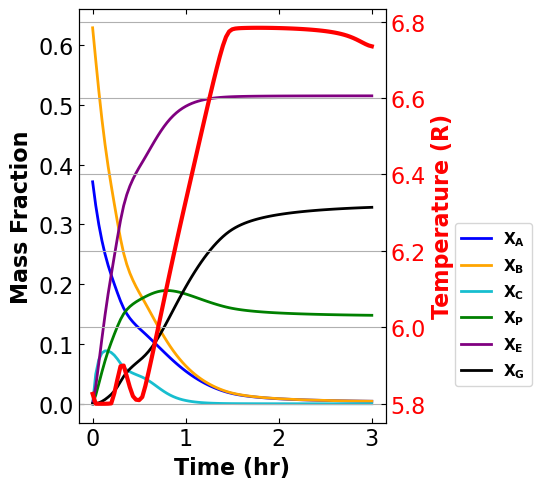

Mass fraction of species at the sample time: [[0.12624845830850107, 0.1862193830257929, 0.046757471464381826, 0.17355594193617804, 0.39515462842947224, 0.07206411683567393], [0.01715656494031917, 0.017942804800379644, 0.0002962075499626941, 0.15960278632524916, 0.5135239981439349, 0.2914776382401545], [0.004203637223406557, 0.004255984267090167, 2.1157981974887073e-05, 0.14798011945709602, 0.5149917837766887, 0.3285473172937436]]

The output variables are:
          XA        XB        XC        XP        XE        XG
0  0.126248  0.186219  0.046757  0.173556  0.395155  0.072064
1  0.017157  0.017943  0.000296  0.159603  0.513524  0.291478
2  0.004204  0.004256  0.000021  0.147980  0.514992  0.328547
The generated data is:
    Time (hr)        XA        XB        XC        XP        XE        XG
0        0.5  0.118682  0.192098  0.049033  0.174136  0.403504  0.062547
1        1.5  0.010023  0.017903  0.001168  0.153845  0.519056  0.298006
2        3.0  0.000000  0.004565  0.000517  0.1

In [23]:
# get the ground-truth simulation of the mass fractions
trace_measured_var = optimal_exp_design_model(trace_optimal_XA0, sample_time, 
                                            temp_profile=trace_optimal_temp)

# make a dataframe of the measured variables
trace_measured_var_df = ground_truth_data(trace_measured_var)

# generate the noisy mass fraction measurements
trace_noisy_mass_frac_var = generate_noisy_mass_fraction(
    trace_measured_var_df,
    species_cols=species,
    standard_dev=std_dict,
)

# compile the generated data into a csv file
trace_data_var = synthetic_data_compiler(sample_time, trace_noisy_mass_frac_var, 
                                       "batch_reactor_trace_optimal_design")

### Reformulate the batch reactor model for parameter estimation

In [24]:
def reform_optimal_exp_design_model(XA0, temp_profile, expert_profile=False):
    """
    Reformulates the variable temperature batch reactor model for parameter estimation

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A
    temp_profile: Pandas series or list,
        Temperature profile from optimal experimental design
    expert_profile: Boolean,
        Specifies if we are using an expert intuition for the temperature profile

    Returns
    -------
    model: Pyomo model of the variable temperature batch reactor
    
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.alpha_1 = pyo.Var(bounds=(0, None), initialize=10)
    model.alpha_2 = pyo.Var(bounds=(0, None), initialize=10)
    model.alpha_3 = pyo.Var(bounds=(0, None), initialize=10)
    model.E1 = pyo.Var(bounds=(0, None), initialize=50)
    model.E2 = pyo.Var(bounds=(0, None), initialize=50)
    model.E3 = pyo.Var(bounds=(0, None), initialize=50)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0)

    # add the temperature variables
    model.T_reparam = pyo.Var(model.t, bounds=(0, 1))

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, model.t, bounds=(0, None))
    model.k = pyo.Var(reaction_number, model.t, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i, t):
        if i == 1:
            return m.k_reparam[i, t] == model.alpha_1 - m.E1 * m.T_reparam[t]
        elif i == 2:
            return m.k_reparam[i, t] == model.alpha_2 - m.E2 * m.T_reparam[t]
        else:
            return m.k_reparam[i, t] == model.alpha_3 - m.E3 * m.T_reparam[t]
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i, t):
        return m.k[i, t] == pyo.exp(m.k_reparam[i, t])
    
    model.k_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)
    # model.dXP = dae.DerivativeVar(model.XP, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXA[t] == - m.k[1, t] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXB[t] == - (m.k[1, t] * m.XA[t] * m.XB[t] + m.k[2, t] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXC[t] == 2 * m.k[1, t] * m.XA[t] * m.XB[t] - 2 * m.k[2, t] * m.XB[t] * m.XC[t] - m.k[3, t] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXE[t] == 2 * m.k[2, t] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXG[t] == 1.5 * m.k[3, t] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA_init = pyo.Constraint(expr=model.XA[t0] == XA0)
    model.XB_init = pyo.Constraint(expr=model.XB[t0] == 1 - model.XA[t0])
    model.XC_init = pyo.Constraint(expr=model.XC[t0] == 0.0)
    model.XE_init = pyo.Constraint(expr=model.XE[t0] == 0.0)
    model.XG_init = pyo.Constraint(expr=model.XG[t0] == 0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=90, scheme="BACKWARD")

    # add the optimal temperature profile
    for indx, t in enumerate(time_vals):
        if not expert_profile:
            model.T_reparam[t].fix(temp_profile[indx])
        else:
            model.T_reparam[t].fix(1/temp_profile[0])
    
    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)
    
    return model

### Estimate the unknown model parameters

In [25]:
# create an experiment class for the data from optimal experiment design
trace_exp = BatchReactorExperiment(
    data=trace_data_var, XA0=trace_optimal_XA0,
    temp_control=trace_optimal_temp,
    const_temp=False,
    doe_solve=True,
)

# combine the low temperature and optimal experiment design data
trace_exp_list = [exp_low, trace_exp]

In [26]:
# estimate the parameters and the covariance matrix
trace_obj, trace_theta_opt, trace_cov_matrix = parameter_covariance_est(trace_exp_list,)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [61]:
print("Estimates of the original parameters:\n", trace_theta_opt)

print("\nCovariance matrix of the estimated parameters:\n", trace_cov_matrix)

# get the scalar metrics of the Fisher information matrix
print("The condition number of the Fisher information matrix is:\n", 
      np.linalg.cond(np.linalg.inv(trace_cov_matrix)))

print("\nThe trace of the Fisher information matrix is:\n", 
      np.trace(np.linalg.inv(trace_cov_matrix)))

Estimates of the original parameters:
 {'alpha_1': 22.75593333537869, 'alpha_2': 27.762724347404404, 'alpha_3': 36.60697191082094, 'E1': 121.64561933054439, 'E2': 145.48669884058208, 'E3': 199.3898981647565}

Covariance matrix of the estimated parameters:
           alpha_1    alpha_2    alpha_3         E1          E2          E3
alpha_1  0.347647   0.030008   0.343603   2.023291    0.172347    2.007739
alpha_2  0.030008   9.069490   9.479595   0.175302   52.731192   55.077122
alpha_3  0.343603   9.479595  11.353996   2.013497   55.086983   66.129894
E1       2.023291   0.175302   2.013497  11.776671    1.006220   11.768871
E2       0.172347  52.731192  55.086983   1.006220  306.590483  320.055668
E3       2.007739  55.077122  66.129894  11.768871  320.055668  385.208472
The condition number of the Fisher information matrix is:
 30516525.938429337

The trace of the Fisher information matrix is:
 54694.1465241753


### Low temperature data plus condition number design

The optimal XA0 for ME-optimality is: 0.3729956252736224
Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes fo

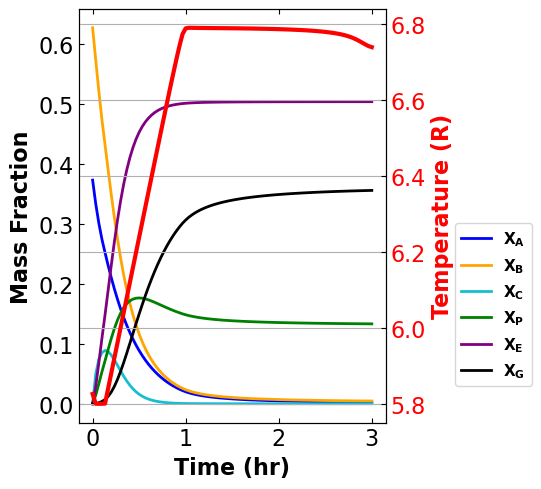

Mass fraction of species at the sample time: [[0.08868878884668577, 0.11626211510422788, 0.01586019215873383, 0.17649410604285673, 0.4528708463904264, 0.14982395145706945], [0.008123808924477519, 0.01049087310149611, 9.494315237745746e-05, 0.13845902577851713, 0.5032833705514734, 0.3395479784916583], [0.0024868884239667194, 0.004600897553976896, 1.4816357876907318e-05, 0.1332881519747731, 0.5037894806454903, 0.35581976504391616]]

The output variables are:
          XA        XB        XC        XP        XE        XG
0  0.088689  0.116262  0.015860  0.176494  0.452871  0.149824
1  0.008124  0.010491  0.000095  0.138459  0.503283  0.339548
2  0.002487  0.004601  0.000015  0.133288  0.503789  0.355820
The generated data is:
    Time (hr)        XA        XB        XC        XP        XE        XG
0        0.5  0.079992  0.120036  0.017206  0.177162  0.462957  0.142646
1        1.5  0.000884  0.010363  0.000964  0.132452  0.508694  0.346642
2        3.0  0.000000  0.004916  0.000510  0.1

In [28]:
# load the design conditions from optimal experimental design
cond_optimal_design = pd.read_csv("condition_number_optimal_design.csv")
cond_optimal_temp = cond_optimal_design["Temperature (1/R)"]
cond_optimal_XA0 = cond_optimal_design["XA"][0]
print("The optimal XA0 for ME-optimality is:", cond_optimal_XA0)

# get the ground-truth simulation of the mass fractions
cond_measured_var = optimal_exp_design_model(cond_optimal_XA0, sample_time, 
                                            temp_profile=cond_optimal_temp)

# make a dataframe of the measured variables
cond_measured_var_df = ground_truth_data(cond_measured_var)

# generate the noisy mass fraction measurements
cond_noisy_mass_frac_var = generate_noisy_mass_fraction(
    cond_measured_var_df,
    species_cols=species,
    standard_dev=std_dict,
)

# compile the generated data into a csv file
cond_data_var = synthetic_data_compiler(sample_time, cond_noisy_mass_frac_var, 
                                       "batch_reactor_cond_optimal_design")

In [29]:
# create an experiment class for the data from optimal experiment design
cond_exp = BatchReactorExperiment(
    data=cond_data_var, XA0=cond_optimal_XA0,
    temp_control=cond_optimal_temp,
    const_temp=False,
    doe_solve=True,
)

# combine the low temperature and optimal experiment design data
cond_exp_list = [exp_low, cond_exp]

# estimate the parameters and the covariance matrix
cond_obj, cond_theta_opt, cond_cov_matrix = parameter_covariance_est(cond_exp_list,)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [62]:
print("Estimates of the original parameters:\n", cond_theta_opt)

print("\nCovariance matrix of the estimated parameters:\n", cond_cov_matrix)

# get the scalar metrics of the Fisher information matrix
print("The condition number of the Fisher information matrix is:\n", 
      np.linalg.cond(np.linalg.inv(cond_cov_matrix)))

print("\nThe trace of the Fisher information matrix is:\n", 
      np.trace(np.linalg.inv(cond_cov_matrix)))

Estimates of the original parameters:
 {'alpha_1': 22.374242578042423, 'alpha_2': 28.180765290998494, 'alpha_3': 36.72452678275326, 'E1': 119.40812257723294, 'E2': 147.91889852987396, 'E3': 200.0466458362116}

Covariance matrix of the estimated parameters:
           alpha_1   alpha_2   alpha_3        E1         E2         E3
alpha_1  0.112633 -0.012514  0.089589  0.659964  -0.074226   0.528714
alpha_2 -0.012514  0.580471  0.498102 -0.072113   3.382683   2.884471
alpha_3  0.089589  0.498102  1.010047  0.534132   2.883491   5.977184
E1       0.659964 -0.072113  0.534132  3.868493  -0.428492   3.155707
E2      -0.074226  3.382683  2.883491 -0.428492  19.718410  16.695311
E3       0.528714  2.884471  5.977184  3.155707  16.695311  35.408373
The condition number of the Fisher information matrix is:
 1687134.055353338

The trace of the Fisher information matrix is:
 43977.87112298399


### High temperature data plus condition number design

In [31]:
# combine the high temperature and optimal experiment design data
cond_exp_list_2 = [exp_high, cond_exp]

# estimate the parameters and the covariance matrix
cond_obj_2, cond_theta_opt_2, cond_cov_matrix_2 = parameter_covariance_est(cond_exp_list_2,)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [63]:
print("Estimates of the original parameters:\n", cond_theta_opt_2)

print("\nCovariance matrix of the estimated parameters:\n", cond_cov_matrix_2)

# get the scalar metrics of the Fisher information matrix
print("The condition number of the Fisher information matrix is:\n", 
      np.linalg.cond(np.linalg.inv(cond_cov_matrix_2)))

print("\nThe trace of the Fisher information matrix is:\n", 
      np.trace(np.linalg.inv(cond_cov_matrix_2)))

Estimates of the original parameters:
 {'alpha_1': 22.685930048483236, 'alpha_2': 20.58915883587761, 'alpha_3': 28.973477033624494, 'E1': 121.21432351772057, 'E2': 100.84829341113176, 'E3': 151.85865182275458}

Covariance matrix of the estimated parameters:
           alpha_1     alpha_2     alpha_3         E1           E2           E3
alpha_1  0.247467    0.567382    0.575048   1.502207     3.480121     3.528800
alpha_2  0.567382   31.991692   34.374353   3.757467   198.359885   213.547659
alpha_3  0.575048   34.374353   37.380241   3.853736   213.123971   232.301089
E1       1.502207    3.757467    3.853736   9.128149    23.065835    23.683974
E2       3.480121  198.359885  213.123971  23.065835  1230.004977  1324.113751
E3       3.528800  213.547659  232.301089  23.683974  1324.113751  1443.786968
The condition number of the Fisher information matrix is:
 29731128.0705255

The trace of the Fisher information matrix is:
 14009.96360482524


## Generate the confidence regions

In [33]:
def likelihood_confidence_ellipse(opt_design_params, opt_design_cov, 
                                  param_index, confidence_level=0.80, 
                                  grid_points=300,):
    # define the parameters and covariance from the low and 
    # optimal design using numpy
    theta_hat_low_opt = np.array([
        opt_design_params["alpha_1"],
        opt_design_params["alpha_2"],
        opt_design_params["alpha_3"],
        opt_design_params["E1"],
        opt_design_params["E2"],
        opt_design_params["E3"]
    ])
    cov_low_opt = cond_cov_matrix.to_numpy()

    # define the parameters and covariance from the combined low and high
    theta_hat_comb = np.array([
        estimated_params_comb["alpha_1"], 
        estimated_params_comb["alpha_2"], 
        estimated_params_comb["alpha_3"],
        estimated_params_comb["E1"], 
        estimated_params_comb["E2"], 
        estimated_params_comb["E3"]])
    cov_comb = cov_matrix_comb.to_numpy()

    # define the parameters and covariance from the high and 
    # optimal design using numpy
    theta_hat_high_opt = np.array([
        cond_theta_opt_2["alpha_1"], 
        cond_theta_opt_2["alpha_2"], 
        cond_theta_opt_2["alpha_3"],
        cond_theta_opt_2["E1"], 
        cond_theta_opt_2["E2"], 
        cond_theta_opt_2["E3"]])
    cov_high_opt = cond_cov_matrix_2.to_numpy()
    
    # get the parameters of interest
    theta_sub_low_opt = theta_hat_low_opt[param_index]
    theta_sub_comb = theta_hat_comb[param_index]
    theta_sub_high_opt = theta_hat_high_opt[param_index]
    
    # get the covariance matrix of interest
    cov_sub_low_opt = cov_low_opt[np.ix_(param_index, param_index)]
    cov_sub_inv_low_opt = np.linalg.inv(cov_sub_low_opt)
    
    cov_sub_comb = cov_comb[np.ix_(param_index, param_index)]
    cov_sub_inv_comb = np.linalg.inv(cov_sub_comb)
    
    cov_sub_high_opt = cov_high_opt[np.ix_(param_index, param_index)]
    cov_sub_inv_high_opt = np.linalg.inv(cov_sub_high_opt)
    
    # define the chi-squared threshold
    cutoff = chi2.ppf(confidence_level, df=2)
    
    # define the grid of the parameters from the low and optimal design
    param_1_grid = np.linspace(
        theta_sub_low_opt[0] - 4 * np.sqrt(cov_sub_low_opt[0,0]),
        theta_sub_low_opt[0] + 4 * np.sqrt(cov_sub_low_opt[0,0]),
        grid_points
    )
    
    param_2_grid = np.linspace(
        theta_sub_low_opt[1] - 4 * np.sqrt(cov_sub_low_opt[1,1]),
        theta_sub_low_opt[1] + 4 * np.sqrt(cov_sub_low_opt[1,1]),
        grid_points
    )
    
    A, B = np.meshgrid(param_1_grid, param_2_grid)
    
    # define the grid of the parameters from the combined low and high
    param_1_grid_comb = np.linspace(
        theta_sub_comb[0] - 4 * np.sqrt(cov_sub_comb[0,0]),
        theta_sub_comb[0] + 4 * np.sqrt(cov_sub_comb[0,0]),
        grid_points
    )
    
    param_2_grid_comb = np.linspace(
        theta_sub_comb[1] - 4 * np.sqrt(cov_sub_comb[1,1]),
        theta_sub_comb[1] + 4 * np.sqrt(cov_sub_comb[1,1]),
        grid_points
    )
    
    A_comb, B_comb = np.meshgrid(param_1_grid_comb, param_2_grid_comb)
    
    # define the grid of the parameters from the high and optimal design
    param_1_grid_high_opt = np.linspace(
        theta_sub_high_opt[0] - 4 * np.sqrt(cov_sub_high_opt[0,0]),
        theta_sub_high_opt[0] + 4 * np.sqrt(cov_sub_high_opt[0,0]),
        grid_points
    )
    
    param_2_grid_high_opt = np.linspace(
        theta_sub_high_opt[1] - 4 * np.sqrt(cov_sub_high_opt[1,1]),
        theta_sub_high_opt[1] + 4 * np.sqrt(cov_sub_high_opt[1,1]),
        grid_points
    )
    
    A_high_opt, B_high_opt = np.meshgrid(param_1_grid_high_opt, param_2_grid_high_opt)
    
    # compute the likelihood ratio statistics
    LR_stats = np.zeros_like(A)
    LR_stats_comb = np.zeros_like(A)
    LR_stats_high_opt = np.zeros_like(A)

    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            # compute the difference between the current parameters 
            # and the estimated parameters
            d = np.array([
                A[i,j] - theta_sub_low_opt[0],
                B[i,j] - theta_sub_low_opt[1]
            ])
            d_comb = np.array([
                A_comb[i,j] - theta_sub_comb[0],
                B_comb[i,j] - theta_sub_comb[1]
            ])
    
            d_high_opt = np.array([
                A_high_opt[i,j] - theta_sub_high_opt[0],
                B_high_opt[i,j] - theta_sub_high_opt[1]
            ])

            # update the likelihood ratio statistics
            LR_stats[i,j] = d @ cov_sub_inv_low_opt @ d
            LR_stats_comb[i,j] = d_comb @ cov_sub_inv_comb @ d_comb
            LR_stats_high_opt[i,j] = d_high_opt @ cov_sub_inv_high_opt @ d_high_opt

    return cutoff, np.array([[A_high_opt, B_high_opt, LR_stats_high_opt], 
                             [A_comb, B_comb, LR_stats_comb], [A, B, LR_stats]])
    
    

In [54]:
def plot_confidence_region(cutoff, LR_mat, labels, fig_name):
    fig = plt.subplots(figsize=(5, 5))

    # high and optimal design color
    high_opt_fill = "#F4A582"
    high_opt_edge = "#D6604D"
    
    # combined low and high color
    comb_fill = "#92C5DE"
    comb_edge = "#0571B0"
    
    # low and optimal design color
    low_opt_fill = "#B8E186"
    low_opt_edge = "#4D9221"
    
    alpha_fill = 0.25
    lw = 2.5

    # define the parameters that need to be scaled for the plots
    scaled_params = ["alpha_1", "alpha_2", "alpha_3"]

    # define a container for all the activation energy
    E_params = ["E1", "E2", "E3"]
    
    # plot the confidence regions
    plt.contourf(LR_mat[0,0], LR_mat[0,1], np.where(LR_mat[0,2] <= cutoff, 1, np.nan), 
                 levels=[0.5, 1.5], colors=[high_opt_fill], alpha=alpha_fill)
    
    plt.contourf(LR_mat[1,0], LR_mat[1,1], np.where(LR_mat[1,2] <= cutoff, 1, np.nan), 
                 levels=[0.5, 1.5], colors=[comb_fill], alpha=alpha_fill)
    
    plt.contourf(LR_mat[2,0], LR_mat[2,1], np.where(LR_mat[2,2] <= cutoff, 1, np.nan), 
                 levels=[0.5, 1.5], colors=[low_opt_fill], alpha=alpha_fill)
    
    # plot the boundaries of the confidence regions
    plt.contour(LR_mat[0,0], LR_mat[0,1], LR_mat[0,2], 
                levels=[cutoff], colors=[high_opt_edge], linewidths=lw,)

    plt.contour(LR_mat[1,0], LR_mat[1,1], LR_mat[1,2], 
                levels=[cutoff], colors=[comb_edge], linewidths=lw,)
    
    plt.contour(LR_mat[2,0], LR_mat[2,1], LR_mat[2,2], 
                levels=[cutoff], colors=[low_opt_edge], linewidths=lw,)

    if fig_name == ["E1", "E3"]:
        # plot the true value of the parameters
        plt.scatter(true_params["E1"], true_params["E3"], marker="*", 
                    color="black", s=220, zorder=100, label="True Value")
        plt.xlim((115, 127))
        plt.ylim((80, 225))
        
    elif fig_name == ["E1", "E2"]:
        plt.scatter(true_params["E1"], true_params["E2"], marker="*", 
                    color="black", s=220, zorder=100, label="True Value")
        plt.xlim((115, 127))
        plt.ylim((30, 170))
        
    elif fig_name == ["E2", "E3"]:
        plt.scatter(true_params["E2"], true_params["E3"], marker="*", 
                    color="black", s=220, zorder=100, label="True Value")
        plt.xlim((30, 170))
        plt.ylim((80, 230))
            
    elif fig_name == ["alpha_1", "alpha_2"]:
        plt.scatter(true_params["alpha_1"], true_params["alpha_2"], marker="*", 
                    color="black", s=220, zorder=100, label="True Value")
        plt.xlim((21.5, 23.8))
        plt.ylim((9, 32))
            
    elif fig_name == ["alpha_1", "alpha_3"]:
        plt.scatter(true_params["alpha_1"], true_params["alpha_3"], marker="*", 
                    color="black", s=220, zorder=100, label="True Value")
        plt.xlim((21.5, 23.8))
        plt.ylim((17, 42))
            
    elif fig_name == ["alpha_2", "alpha_3"]:
        plt.scatter(true_params["alpha_2"], true_params["alpha_3"], marker="*", 
                    color="black", s=220, zorder=100, label="True Value")
        plt.xlim((9, 32))
        plt.ylim((17, 42))
            
    elif fig_name == ["alpha_1", "E1"]:
        plt.scatter(true_params["alpha_1"], true_params["E1"], marker="*", 
                    color="black", s=220, zorder=100, label="True Value")
        plt.xlim((21.5, 23.8))
        plt.ylim((115, 128))
            
    elif fig_name == ["alpha_2", "E2"]:
        plt.scatter(true_params["alpha_2"], true_params["E2"], marker="*", 
                    color="black", s=220, zorder=100, label="True Value")
        plt.xlim((9, 32))
        plt.ylim((30, 170))
            
    elif fig_name == ["alpha_3", "E3"]:
        plt.scatter(true_params["alpha_3"], true_params["E3"], marker="*", 
                    color="black", s=220, zorder=100,)
        plt.xlim((17, 42))
        plt.ylim((80, 230))

    # format the axis to look good
    plt.xlabel(labels[0], fontsize=18, fontweight="bold")
    plt.ylabel(labels[1], fontsize=18, fontweight="bold")
    
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.tick_params(direction="in",top=True, right=True)
    
    # # add the legend for the confidence ellipse
    # legend_elements = [
    #     Patch(facecolor=high_opt_fill, edgecolor=high_opt_edge, label='High and Optimal Experiments'),
    #     Patch(facecolor=comb_fill, edgecolor=comb_edge, label='High and Low Experiment'),
    #     Patch(facecolor=low_opt_fill, edgecolor=low_opt_edge, label='Low and Optimal Experiment'),
    #     mlines.Line2D([], [], color='black', marker='*', linestyle='None', markersize=12, 
    #                   label='True Parameter Values')
    # ]
    
    # plt.legend(handles=legend_elements, 
    #            prop={"weight":"bold", "size": 11}, bbox_to_anchor=(1, 1.2), frameon=False)
    
    plt.tight_layout()
    plt.savefig(f"confidence_region_{fig_name[0]}_{fig_name[1]}.png", dpi=600, bbox_inches="tight")
    plt.show()

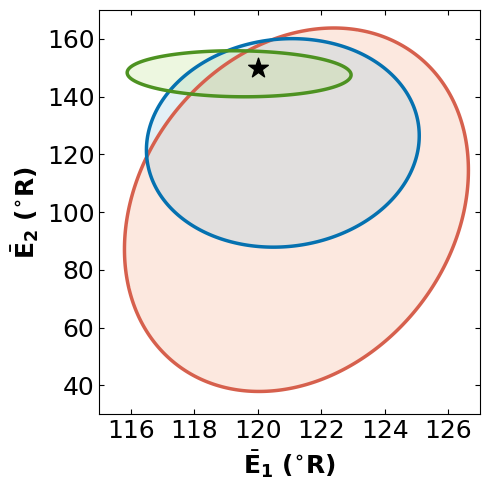

In [35]:
cutoff, LR_mat = likelihood_confidence_ellipse(cond_theta_opt, cond_cov_matrix, 
                                               param_index=[3, 4],)

plot_confidence_region(cutoff, LR_mat, labels=[r"$\bar{\mathbf{E}}$$\mathbf{_1}$ ($\mathbf{^{\circ}}$R)",
                                               r"$\bar{\mathbf{E}}$$\mathbf{_2}$ ($\mathbf{^{\circ}}$R)"], 
                       fig_name=["E1", "E2"])

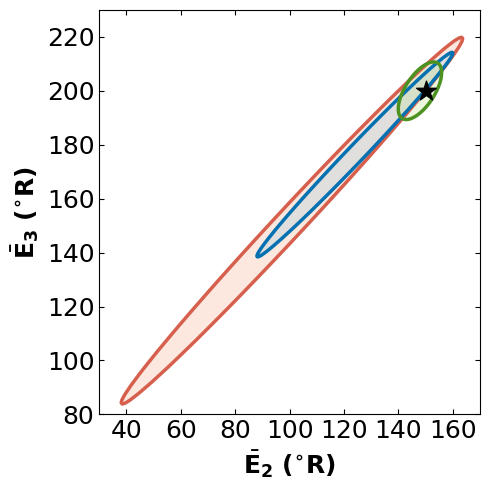

In [36]:
cutoff, LR_mat = likelihood_confidence_ellipse(cond_theta_opt, cond_cov_matrix, 
                                               param_index=[4, 5],)

plot_confidence_region(cutoff, LR_mat, labels=[r"$\bar{\mathbf{E}}$$\mathbf{_2}$ ($\mathbf{^{\circ}}$R)",
                                               r"$\bar{\mathbf{E}}$$\mathbf{_3}$ ($\mathbf{^{\circ}}$R)"], 
                      fig_name=["E2", "E3"])

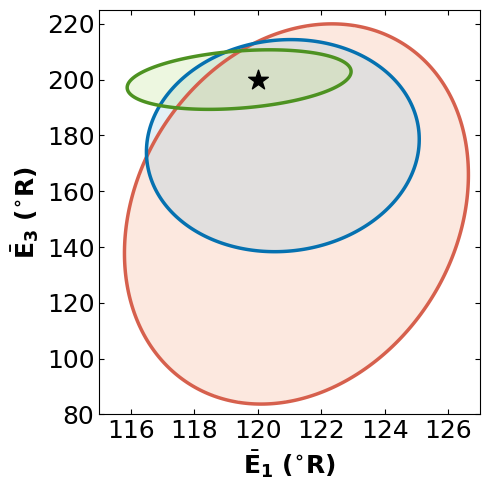

In [55]:
cutoff, LR_mat = likelihood_confidence_ellipse(cond_theta_opt, cond_cov_matrix, 
                                               param_index=[3, 5],)

plot_confidence_region(cutoff, LR_mat, labels=[r"$\bar{\mathbf{E}}$$\mathbf{_1}$ ($\mathbf{^{\circ}}$R)",
                                               r"$\bar{\mathbf{E}}$$\mathbf{_3}$ ($\mathbf{^{\circ}}$R)"], 
                      fig_name=["E1", "E3"])

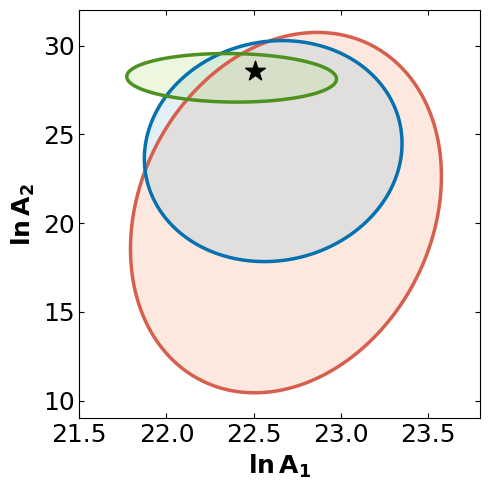

In [49]:
cutoff, LR_mat = likelihood_confidence_ellipse(cond_theta_opt, cond_cov_matrix, 
                                               param_index=[0, 1],)

plot_confidence_region(cutoff, LR_mat, labels=[r"$\mathbf{ln \, A{_1}}$", r"$\mathbf{ln \, A{_2}}$"], 
                       fig_name=["alpha_1", "alpha_2"])

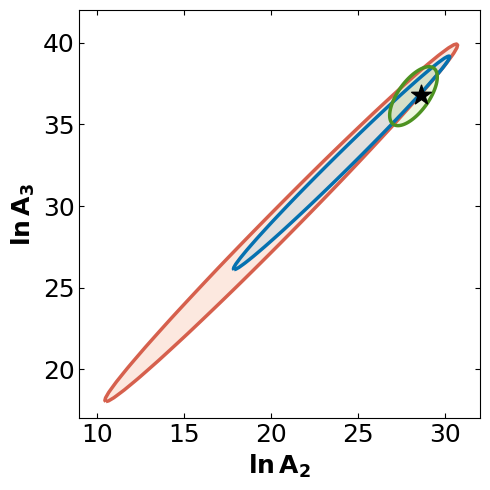

In [39]:
cutoff, LR_mat = likelihood_confidence_ellipse(cond_theta_opt, cond_cov_matrix, 
                                               param_index=[1, 2],)

plot_confidence_region(cutoff, LR_mat, labels=[r"$\mathbf{ln \, A{_2}}$", r"$\mathbf{ln \, A{_3}}$"], 
                       fig_name=["alpha_2", "alpha_3"])

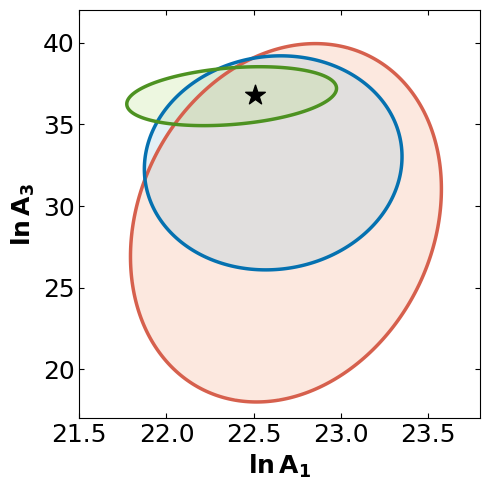

In [50]:
cutoff, LR_mat = likelihood_confidence_ellipse(cond_theta_opt, cond_cov_matrix, 
                                               param_index=[0, 2],)

plot_confidence_region(cutoff, LR_mat, labels=[r"$\mathbf{ln \, A{_1}}$", r"$\mathbf{ln \, A{_3}}$"], 
                       fig_name=["alpha_1", "alpha_3"])

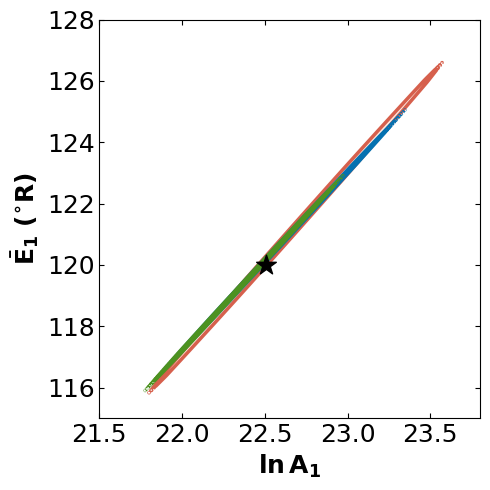

In [51]:
cutoff, LR_mat = likelihood_confidence_ellipse(cond_theta_opt, cond_cov_matrix, 
                                               param_index=[0, 3],)

plot_confidence_region(cutoff, LR_mat, labels=[r"$\mathbf{ln \, A{_1}}$", 
                                              r"$\bar{\mathbf{E}}$$\mathbf{_1}$ ($\mathbf{^{\circ}}$R)"],
                       fig_name=["alpha_1", "E1"])

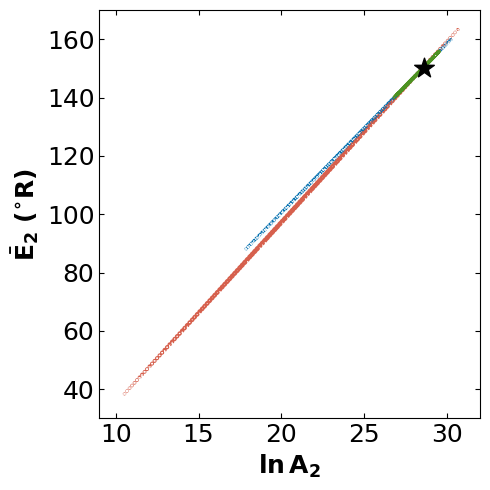

In [52]:
cutoff, LR_mat = likelihood_confidence_ellipse(cond_theta_opt, cond_cov_matrix, 
                                               param_index=[1, 4],)

plot_confidence_region(cutoff, LR_mat, labels=[r"$\mathbf{ln \, A{_2}}$", 
                                              r"$\bar{\mathbf{E}}$$\mathbf{_2}$ ($\mathbf{^{\circ}}$R)"],
                       fig_name=["alpha_2", "E2"])

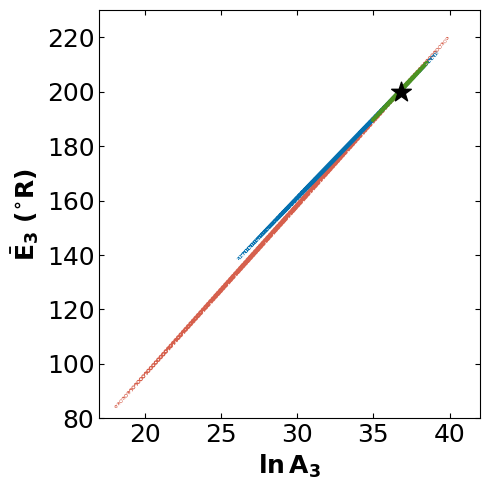

In [53]:
cutoff, LR_mat = likelihood_confidence_ellipse(cond_theta_opt, cond_cov_matrix, 
                                               param_index=[2, 5],)

plot_confidence_region(cutoff, LR_mat, labels=[r"$\mathbf{ln \, A{_3}}$", 
                                              r"$\bar{\mathbf{E}}$$\mathbf{_3}$ ($\mathbf{^{\circ}}$R)"],
                       fig_name=["alpha_3", "E3"])